In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,roc_auc_score

In [2]:
data=pd.read_csv("cs-training.csv")
df=data.copy()
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

In [4]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

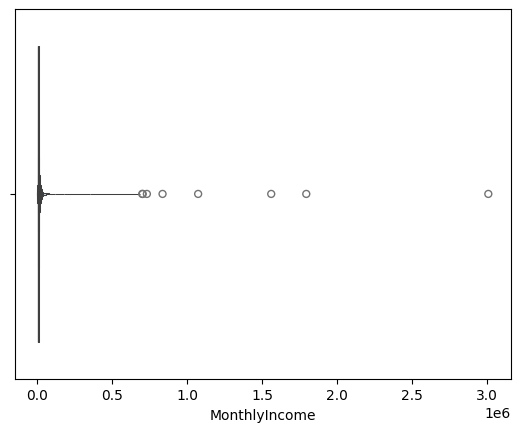

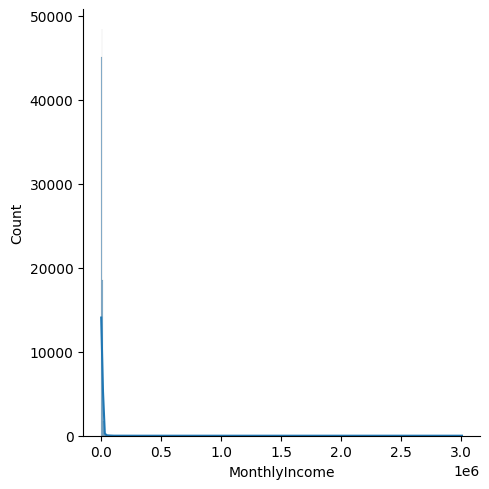

In [5]:
##burada aylık gelirin dağılımını inceleyelim
sns.boxenplot(x=df["MonthlyIncome"])
sns.displot(df["MonthlyIncome"], kde=True)

In [6]:
df["MonthlyIncome"]=df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())

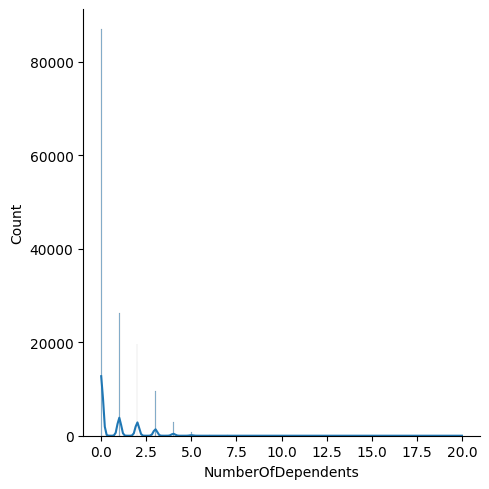

In [7]:
df["NumberOfDependents"]

sns.displot(df["NumberOfDependents"], kde=True)

In [8]:
df["NumberOfDependents"]=df["NumberOfDependents"].fillna(0)

<Axes: xlabel='age'>

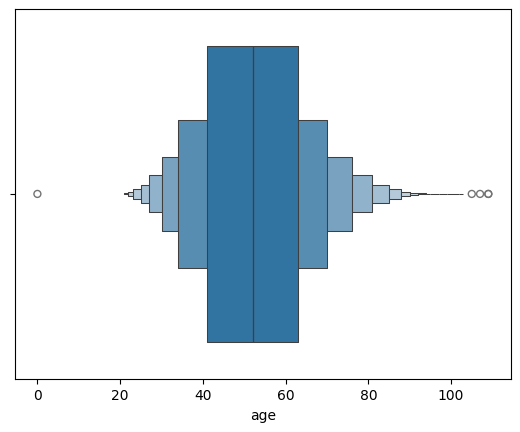

In [9]:
sns.boxenplot(x=df["age"])

<Axes: xlabel='age'>

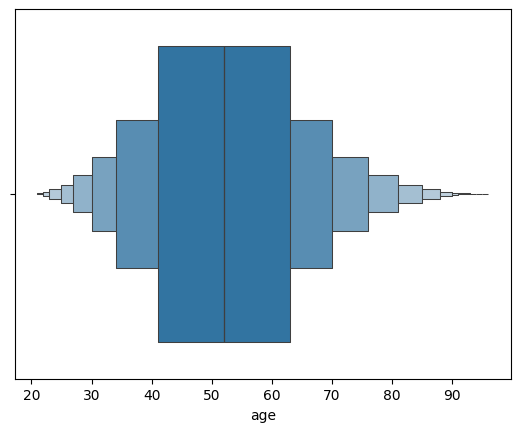

In [10]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    alt_sinir = Q1 - 1.5 * IQR
    ust_sinir = Q3 + 1.5 * IQR
    df_clean = df[(df[column] >= alt_sinir) & (df[column] <= ust_sinir)]
    return df_clean
df = remove_outliers(df, "age")
sns.boxenplot(x=df["age"])

<Axes: xlabel='RevolvingUtilizationOfUnsecuredLines', ylabel='Density'>

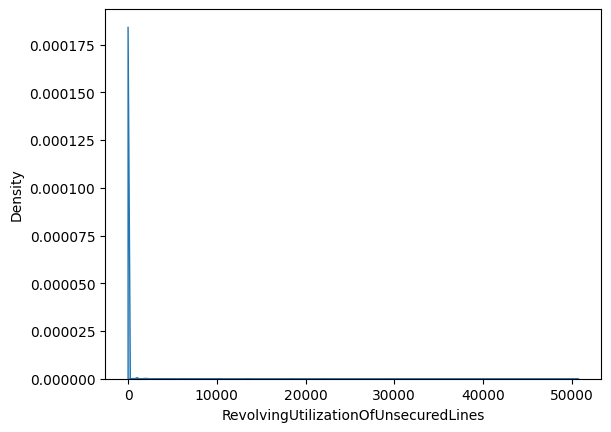

In [11]:
sns.kdeplot(x=df["RevolvingUtilizationOfUnsecuredLines"], fill=True)

In [12]:
# 1.0'dan büyük her şeyi 1.0 yap (Çünkü limit %100 dolmuş demektir)
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].apply(lambda x: 1 if x > 1 else x)

<Axes: xlabel='RevolvingUtilizationOfUnsecuredLines', ylabel='Density'>

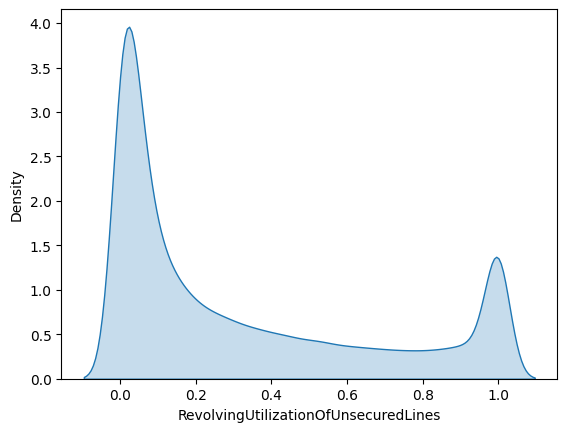

In [13]:
sns.kdeplot(x=df["RevolvingUtilizationOfUnsecuredLines"], fill=True)

<Axes: xlabel='NumberOfTime30-59DaysPastDueNotWorse'>

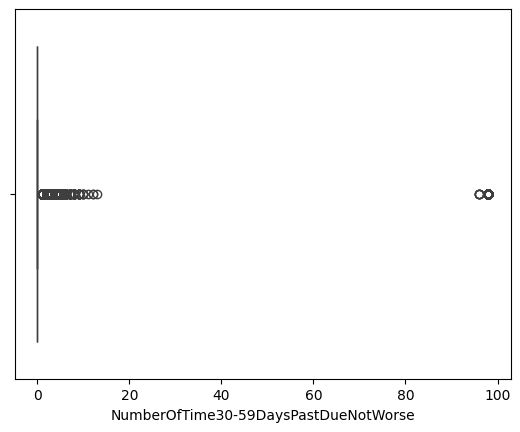

In [14]:
sns.boxplot(x=df["NumberOfTime30-59DaysPastDueNotWorse"], fill=True)

In [15]:
# Sadece 90'dan küçük olanları tut (96 ve 98'i ele)
df = df[df['NumberOfTime30-59DaysPastDueNotWorse'] < 90]

<Axes: xlabel='NumberOfTime30-59DaysPastDueNotWorse'>

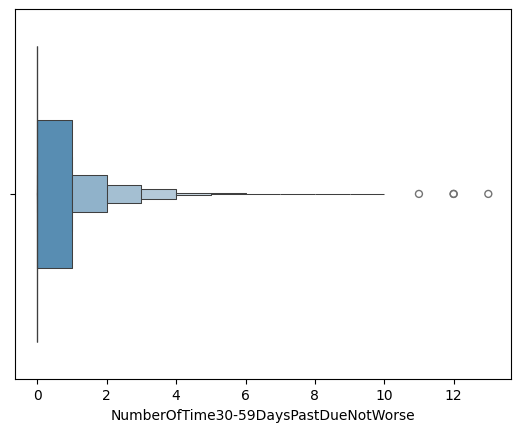

In [16]:
sns.boxenplot(x=df["NumberOfTime30-59DaysPastDueNotWorse"], fill=True)

count    149685.000000
mean        353.695403
std        2039.890502
min           0.000000
25%           0.176064
50%           0.367139
75%           0.869710
max      329664.000000
Name: DebtRatio, dtype: float64

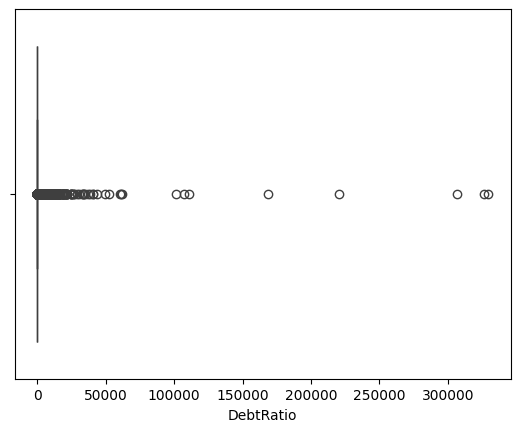

In [17]:
sns.boxplot(x=df["DebtRatio"], fill=True)
df["DebtRatio"].describe()

In [18]:
# Geliri olanlar
has_income = df[df['MonthlyIncome'] > 0]['DebtRatio']
# Geliri olmayanlar veya 0 olanlar
no_income = df[(df['MonthlyIncome'] == 0) | (df['MonthlyIncome'].isna())]['DebtRatio']

In [19]:
# 95. persentil üzerini baskılama (Winsorization)
upper_limit = df['DebtRatio'].quantile(0.95)
df['DebtRatio'] = df['DebtRatio'].apply(lambda x: upper_limit if x > upper_limit else x)

<Axes: xlabel='NumberOfDependents'>

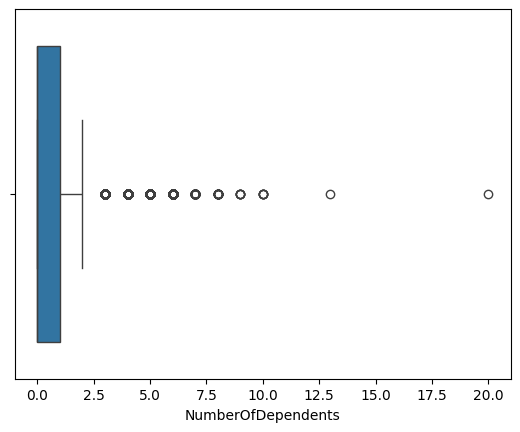

In [20]:
df["NumberOfDependents"].describe()
sns.boxplot(x=df["NumberOfDependents"], fill=True)

In [21]:
remove_outliers(df, "NumberOfOpenCreditLinesAndLoans")

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,149998,0,0.246044,58,0,2452.000000,5400.0,18,0,1,0,0.0
149998,149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


<Axes: xlabel='NumberOfOpenCreditLinesAndLoans'>

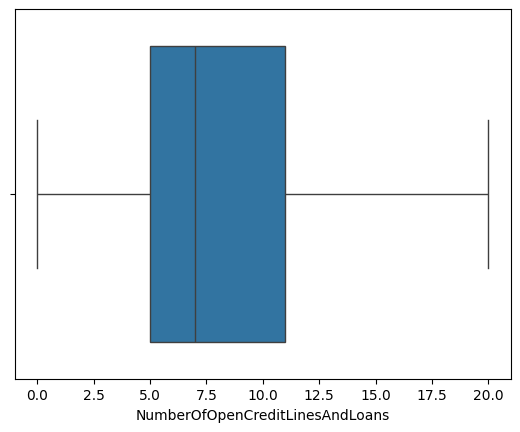

In [22]:
df=remove_outliers(df, "NumberOfOpenCreditLinesAndLoans")
sns.boxplot(x=df["NumberOfOpenCreditLinesAndLoans"], fill=True)

count    145705.00000
mean          0.09198
std           0.48882
min           0.00000
25%           0.00000
50%           0.00000
75%           0.00000
max          17.00000
Name: NumberOfTimes90DaysLate, dtype: float64

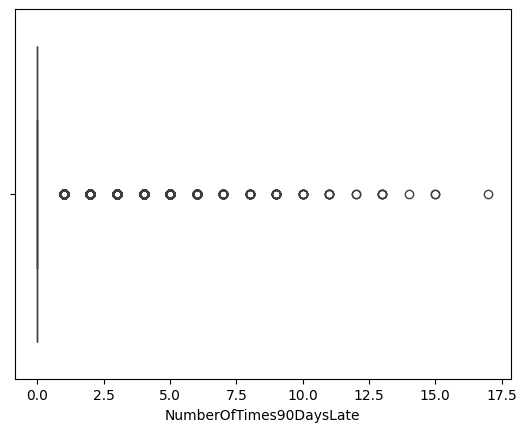

In [23]:
sns.boxplot(x="NumberOfTimes90DaysLate", data=df, fill=True)
df["NumberOfTimes90DaysLate"].describe()  

In [24]:



df.loc[df['NumberOfTimes90DaysLate'] > 10, 'NumberOfTimes90DaysLate'] = 10

In [25]:
df["NumberOfTimes90DaysLate"].describe()

count    145705.000000
mean          0.091692
std           0.481775
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          10.000000
Name: NumberOfTimes90DaysLate, dtype: float64

In [26]:

# Örnek: 10'dan büyük değerleri 10'a sabitle
df['NumberRealEstateLoansOrLines'] = df['NumberRealEstateLoansOrLines'].apply(lambda x: 10 if x > 10 else x)
df["NumberRealEstateLoansOrLines"].describe()

count    145705.000000
mean          0.987029
std           1.042031
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max          10.000000
Name: NumberRealEstateLoansOrLines, dtype: float64

<Axes: xlabel='NumberOfTime60-89DaysPastDueNotWorse'>

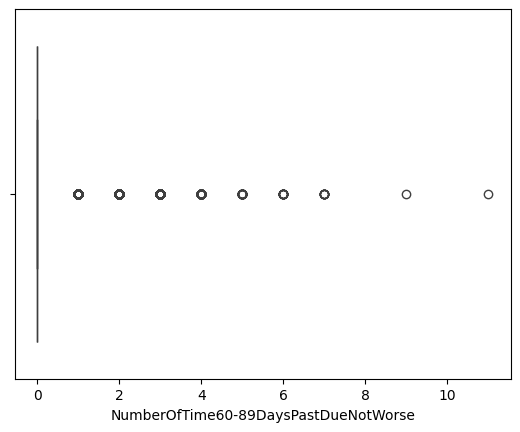

In [27]:
sns.boxplot(x="NumberOfTime60-89DaysPastDueNotWorse", data=df, fill=True)

In [28]:
# 10 ve üzerini 10'a sabitle
df.loc[df['NumberOfDependents'] > 10, 'NumberOfDependents'] = 10
df["NumberOfDependents"].describe()


count    145705.000000
mean          0.738183
std           1.107227
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          10.000000
Name: NumberOfDependents, dtype: float64

In [29]:
df["SeriousDlqin2yrs"].describe()

count    145705.000000
mean          0.065866
std           0.248049
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: SeriousDlqin2yrs, dtype: float64

In [30]:
df.isnull().sum()   

Unnamed: 0                              0
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

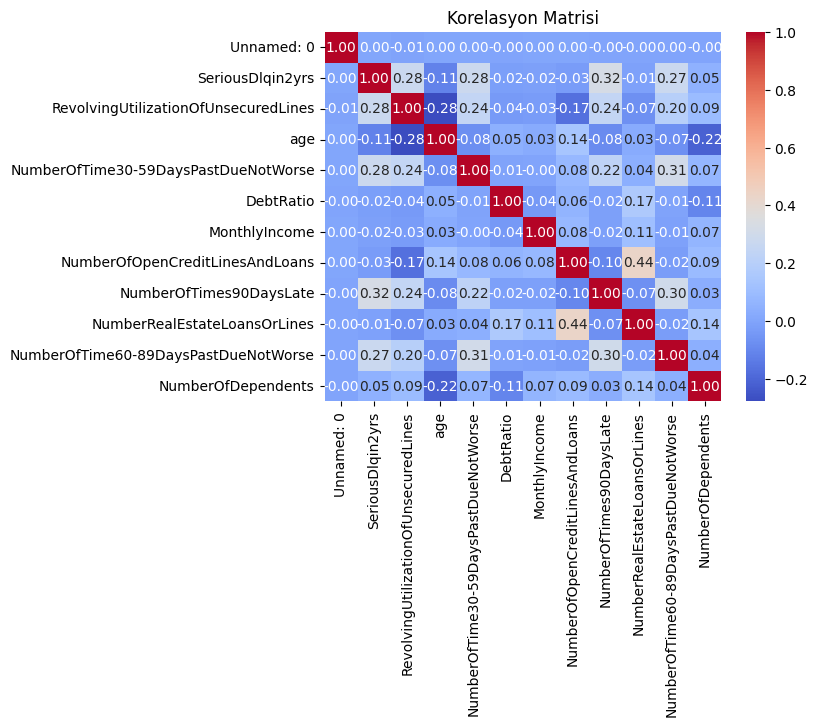

In [31]:
corr=df.corr()
plt.Figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasyon Matrisi")
plt.show()

In [32]:
X=df.drop("SeriousDlqin2yrs", axis=1)
y=df["SeriousDlqin2yrs"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [33]:
ratio=27202 / 1939
model = XGBClassifier(
    scale_pos_weight=ratio,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)   
 

c:\Users\Vedat\Desktop\Kredi\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:32:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [34]:
accuracy_score=roc_auc_score(y_test, y_pred_proba)
print("ROC AUC Score:", accuracy_score)
print("n sınıf raporu:")
print(classification_report(y_test, y_pred))

ROC AUC Score: 0.8699941347637007
n sınıf raporu:
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27202
           1       0.22      0.78      0.34      1939

    accuracy                           0.80     29141
   macro avg       0.60      0.79      0.61     29141
weighted avg       0.93      0.80      0.85     29141



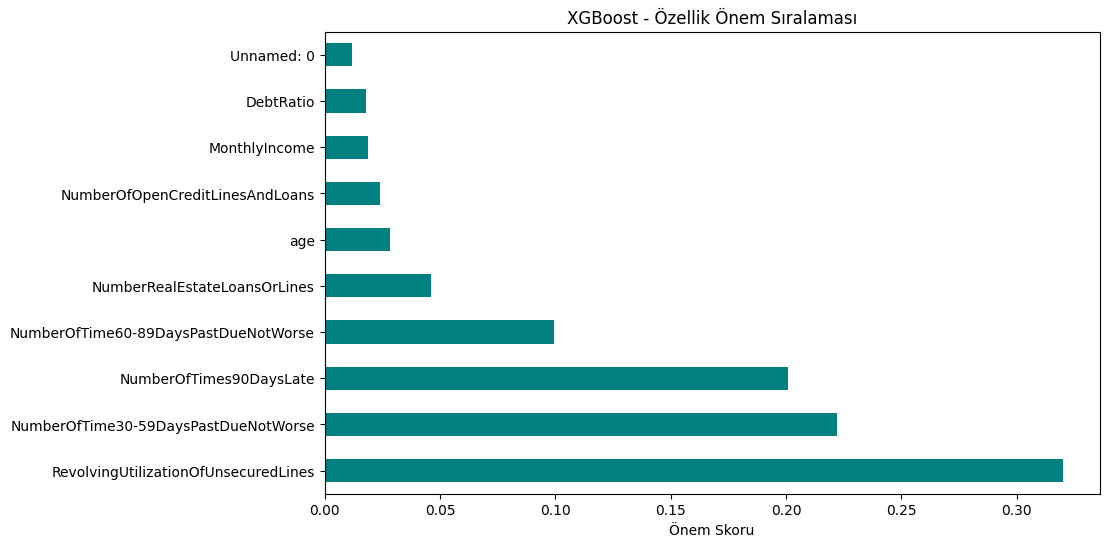

In [35]:
feat_importances = pd.Series(model.feature_importances_, index=X.columns)

# En önemli 10 özelliği çizdir
plt.figure(figsize=(10,6))
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("XGBoost - Özellik Önem Sıralaması")
plt.xlabel("Önem Skoru")
plt.show()

In [36]:
##risk olasılık hesaplama
y_pred_proba = model.predict_proba(X_test)[:, 1]
credit_scroe=(1-y_pred_proba)*1000
results = pd.DataFrame({
    "Gerçek Değer": y_test,
    "Tahmin Edilen Olasılık": y_pred_proba,
    "Kredi Skoru": credit_scroe
})
print(results.head(10))

        Gerçek Değer  Tahmin Edilen Olasılık  Kredi Skoru
24506              0                0.420516   579.484314
100197             0                0.311355   688.644897
111615             0                0.245454   754.546143
61932              1                0.869912   130.088150
83297              0                0.448435   551.564697
141058             0                0.554598   445.401550
39030              0                0.245540   754.459778
79890              0                0.121588   878.412231
9433               0                0.171538   828.462341
95201              0                0.911291    88.709175


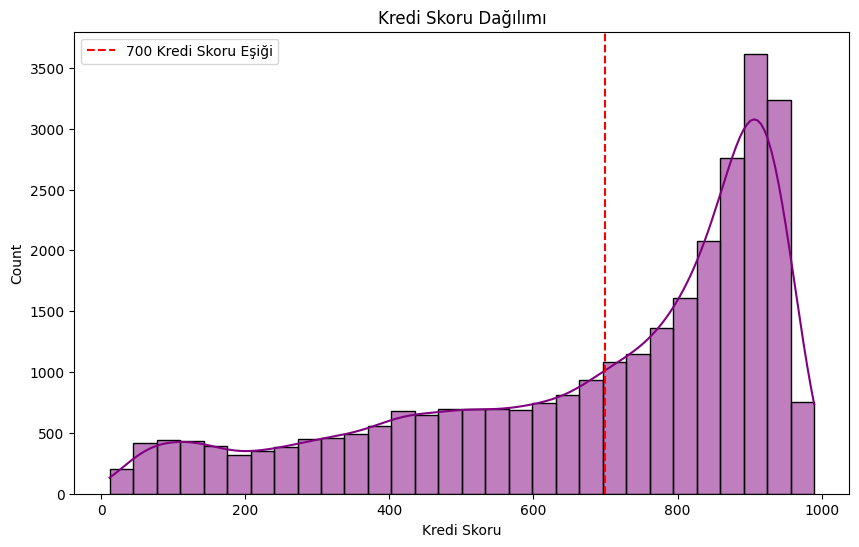

In [46]:
plt.figure(figsize=(10,6))
sns.histplot(results["Kredi Skoru"], bins=30, kde=True, color='purple')
plt.axvline(x=700, color='red', linestyle='--', label='700 Kredi Skoru Eşiği')
plt.title("Kredi Skoru Dağılımı")
plt.xlabel("Kredi Skoru")
plt.legend()

plt.show()
grafik=pd.DataFrame({
    "Kredi Skoru": results["Kredi Skoru"],
    "Gerçek Değer": results["Gerçek Değer"]
})
grafik.to_csv('credit_score_results.csv', index=False)

In [38]:
import joblib

# Modeli kaydet
joblib.dump(model, 'kredi_risk_modeli_vedat.pkl')

# Temizlenmiş veriyi kaydet
df.to_csv('temizlenmiş_kredi_verisi.csv', index=False)
print("Model ve veri başarıyla kaydedildi!")

Model ve veri başarıyla kaydedildi!


In [39]:
X_test_with_results = X_test.copy()
X_test_with_results["Gerçek Değer"] = y_test    
X_test_with_results["Tahmin Edilen Olasılık"] = y_pred_proba
X_test_with_results["Kredi Skoru"] = credit_scroe   
X_test_with_results.to_csv('PowerBI_Icin_Veri.csv', index=False)

In [45]:
importance_scores=model.feature_importances_
feature_names=X.columns
feature_importance_df=pd.DataFrame({"Feature": feature_names, "Importance": importance_scores}) 
feature_importance_df=feature_importance_df.sort_values(by="Importance", ascending=False)
importance_df=feature_importance_df.sort_values(by="Importance", ascending=False)
importance_df.to_csv('feature_importance.csv', index=False) 